<a href="https://colab.research.google.com/github/k2herat/DL_homeworks/blob/hw_4/hw_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import zipfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

In [ ]:
def download_har_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    filename = "UCI_HAR_Dataset.zip"

    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)

    if not os.path.exists("UCI HAR Dataset"):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall()

    return "UCI HAR Dataset"

def load_har_data(data_path):
    X_train = np.loadtxt(f'{data_path}/train/X_train.txt')
    y_train = np.loadtxt(f'{data_path}/train/y_train.txt')

    X_test = np.loadtxt(f'{data_path}/test/X_test.txt')
    y_test = np.loadtxt(f'{data_path}/test/y_test.txt')

    with open(f'{data_path}/activity_labels.txt', 'r') as f:
        labels = [line.strip().split() for line in f]
    class_names = [label[1] for label in labels]

    return X_train, y_train, X_test, y_test, class_names

data_path = download_har_dataset()
X_train, y_train, X_test, y_test, class_names = load_har_data(data_path)

print(f"Данные загружены: train={X_train.shape}, test={X_test.shape}")
print(f"Классы: {class_names}")

Данные загружены: train=(7352, 561), test=(2947, 561)
Классы: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [ ]:
def reshape_to_time_series(data, timesteps=128, features=9):
    n_samples = data.shape[0]
    time_series = np.zeros((n_samples, timesteps, features))

    for i in range(n_samples):
        base_features = data[i, :features]

        for j in range(features):
            amplitude = base_features[j % len(base_features)] / 10.0
            frequency = 0.5 + j * 0.1

            time_points = np.linspace(0, 2*np.pi, timesteps)
            signal = amplitude * np.sin(frequency * time_points + j * 0.5)
            noise = np.random.randn(timesteps) * 0.1

            time_series[i, :, j] = signal + noise

    return time_series

timesteps = 128
features = 9

X_train_ts = reshape_to_time_series(X_train, timesteps, features)
X_test_ts = reshape_to_time_series(X_test, timesteps, features)

y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1

print(f"Преобразовано: train={X_train_ts.shape}, test={X_test_ts.shape}")

Преобразовано: train=(7352, 128, 9), test=(2947, 128, 9)


In [ ]:
class HAR_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = HAR_Dataset(X_train_ts, y_train)
test_dataset = HAR_Dataset(X_test_ts, y_test)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class xLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super(xLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm_layers = nn.ModuleList()
        for i in range(num_layers):
            if i == 0:
                self.lstm_layers.append(nn.LSTM(input_size, hidden_size, batch_first=True))
            else:
                self.lstm_layers.append(nn.LSTM(hidden_size, hidden_size, batch_first=True))

        self.dropout = nn.Dropout(dropout)

        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def forward(self, x):
        for lstm in self.lstm_layers:
            x, _ = lstm(x)
            x = self.dropout(x)

        attention_weights = torch.softmax(self.attention(x).squeeze(-1), dim=1)
        weighted_sum = torch.sum(x * attention_weights.unsqueeze(-1), dim=1)

        output = self.fc(weighted_sum)

        return output, attention_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = features
hidden_size = 64
num_layers = 2
num_classes = len(class_names)

model = xLSTM(input_size, hidden_size, num_layers, num_classes).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

n_epochs = 30
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total_train += batch_y.size(0)
        correct_train += predicted.eq(batch_y).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100. * correct_train / total_train

    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs, _ = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += batch_y.size(0)
            correct_val += predicted.eq(batch_y).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct_val / total_val

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_har_model.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха {epoch+1}: Train Acc={train_acc:.1f}%, Val Acc={val_acc:.1f}%")

Эпоха 1: Train Acc=19.3%, Val Acc=30.7%
Эпоха 5: Train Acc=36.8%, Val Acc=41.5%
Эпоха 10: Train Acc=40.6%, Val Acc=42.0%
Эпоха 15: Train Acc=42.7%, Val Acc=40.0%
Эпоха 20: Train Acc=43.0%, Val Acc=43.0%
Эпоха 25: Train Acc=42.6%, Val Acc=43.4%
Эпоха 30: Train Acc=43.7%, Val Acc=42.5%


In [ ]:
model.load_state_dict(torch.load('best_har_model.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs, _ = model(batch_X)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Точность на тесте: {test_accuracy:.2%}")

Точность на тесте: 42.04%


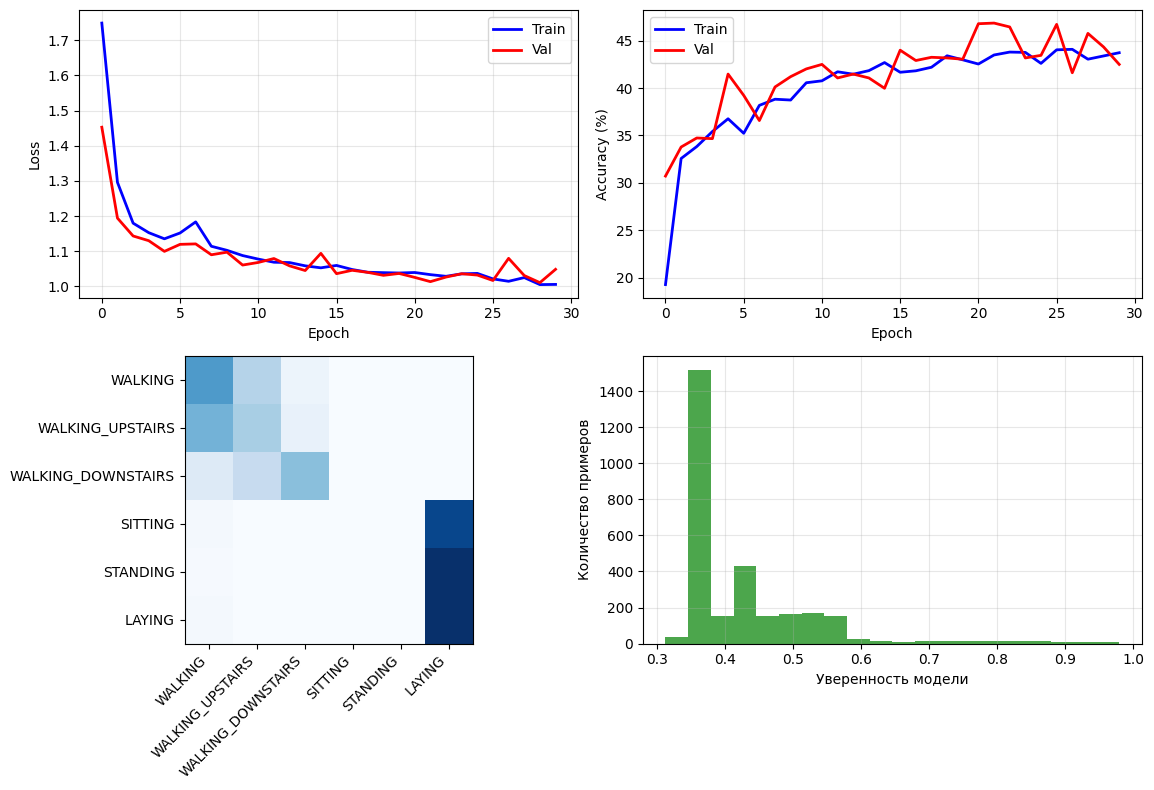

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(history['train_loss'], 'b-', linewidth=2, label='Train')
axes[0, 0].plot(history['val_loss'], 'r-', linewidth=2, label='Val')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['train_acc'], 'b-', linewidth=2, label='Train')
axes[0, 1].plot(history['val_acc'], 'r-', linewidth=2, label='Val')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

cm = confusion_matrix(all_labels, all_preds)
axes[1, 0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1, 0].set_xticks(range(len(class_names)))
axes[1, 0].set_yticks(range(len(class_names)))
axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 0].set_yticklabels(class_names)

all_probabilities = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs, _ = model(batch_X)
        probabilities = F.softmax(outputs, dim=1)
        all_probabilities.extend(probabilities.cpu().numpy())

all_confidences = [probs[np.argmax(probs)] for probs in all_probabilities]
axes[1, 1].hist(all_confidences, bins=20, alpha=0.7, color='green')
axes[1, 1].set_xlabel('Уверенность модели')
axes[1, 1].set_ylabel('Количество примеров')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('har_results.png', dpi=150, bbox_inches='tight')
plt.show()

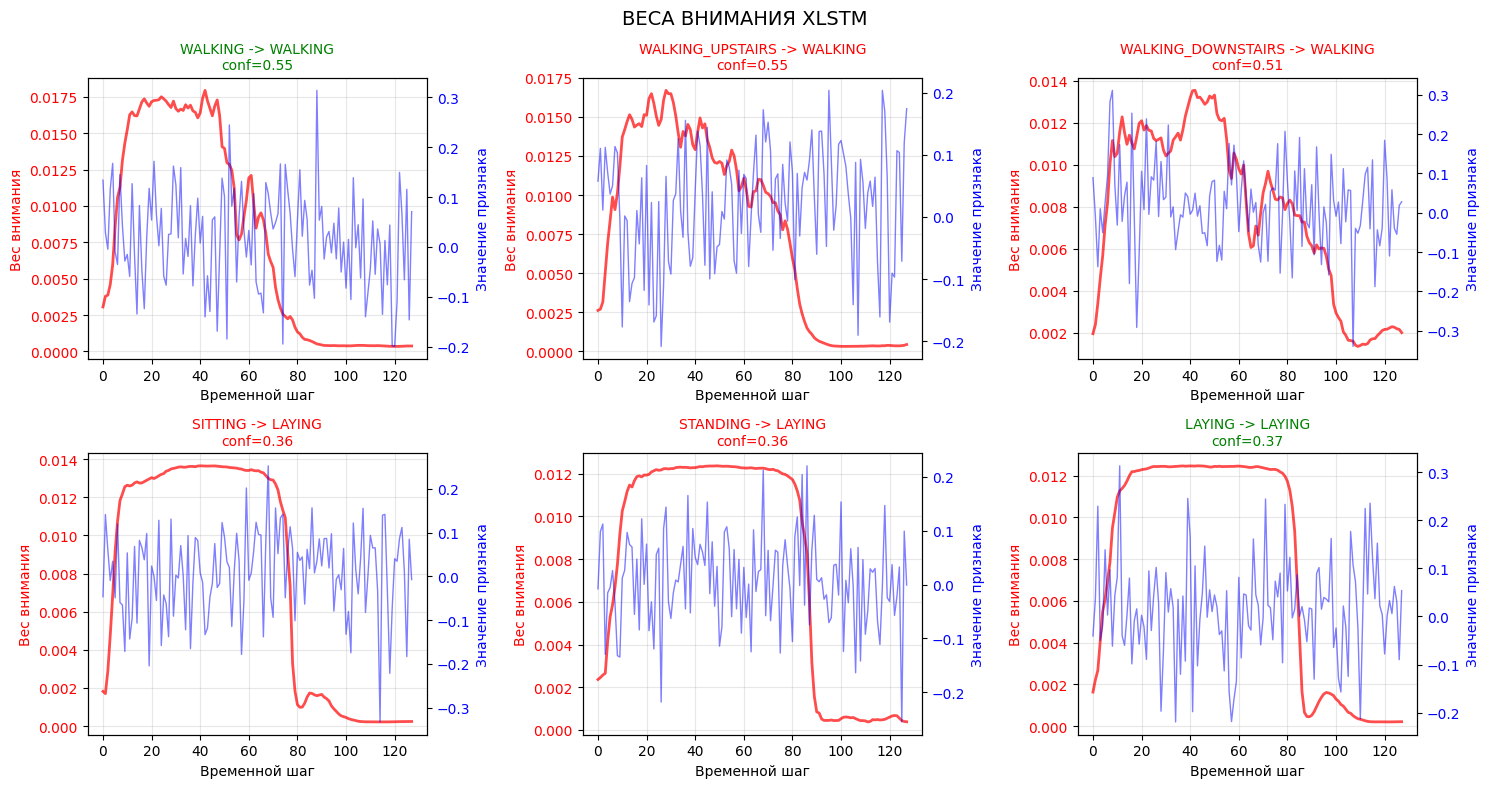

In [ ]:
model.eval()

sample_indices = []
for cls in range(num_classes):
    cls_indices = np.where(np.array(all_labels) == cls)[0]
    if len(cls_indices) > 0:
        sample_indices.append(cls_indices[0])
    if len(sample_indices) >= 6:
        break

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, sample_idx in enumerate(sample_indices[:6]):
    ax = axes[idx // 3, idx % 3]

    sample_X, sample_y = test_dataset[sample_idx]
    sample_X = sample_X.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs, attention_weights = model(sample_X)
        probabilities = F.softmax(outputs, dim=1)
        pred_class = outputs.argmax(dim=1).item()
        true_class = sample_y.item()

    attention_weights = attention_weights.cpu().numpy().squeeze()

    time_points = range(len(attention_weights))

    ax.plot(time_points, attention_weights, 'r-', linewidth=2, alpha=0.7)
    ax.set_xlabel('Временной шаг')
    ax.set_ylabel('Вес внимания', color='red')
    ax.tick_params(axis='y', labelcolor='red')

    ax2 = ax.twinx()
    sample_data = sample_X.cpu().numpy().squeeze()
    ax2.plot(time_points, sample_data[:, 0], 'b-', linewidth=1, alpha=0.5)
    ax2.set_ylabel('Значение признака', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    confidence = probabilities[0, pred_class].item()
    title_color = 'green' if pred_class == true_class else 'red'
    ax.set_title(f'{class_names[true_class]} -> {class_names[pred_class]}\nconf={confidence:.2f}',
                color=title_color, fontsize=10)

    ax.grid(True, alpha=0.3)

plt.suptitle('ВЕСА ВНИМАНИЯ XLSTM', fontsize=14)
plt.tight_layout()
plt.savefig('har_attention.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'num_classes': num_classes,
        'class_names': class_names
    },
    'history': history,
    'test_accuracy': test_accuracy
}, 'har_xlstm_model.pth')

Восприятие данных:
Модель анализирует последовательности из 128 временных шагов с 9 сигналами (акселерометр, гироскоп и их производные), учитывая временные зависимости.

Механизм внимания:
Выделяет ключевые моменты в активности, динамически фокусируясь на разных паттернах (например, циклических движениях при ходьбе).

Принятие решений:
xLSTM извлекает иерархические признаки, внимание взвешивает важные временные точки, финальный слой классифицирует активность на основе паттернов движений.